```{toctree}
:maxdepth: 3
:caption: Contents:

# Walkthrough Example

General workflow of oceanicospy library for new users

## Import general libraries

In [68]:
#import general libraries used on several sections
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import glob
from pathlib import Path
import shutil

In [52]:
 # Compact matplotlib style for clean, consistent figures across the notebook
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['axes.xmargin'] = 0
plt.rcParams['axes.ymargin'] = 0
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['xtick.major.width'] = 0.4
plt.rcParams['ytick.major.width'] = 0.4
plt.rcParams['lines.linewidth'] = 0.9

## Observations

### Import library

In [38]:
from oceanicospy.observations import pressure_sensors,weather_stations,AWAC,\
                                    WaveBuoy,ctd,HOBO_Temp,HOBO_TempCond

### Pressure sensors: AQuaLogger and RBR

Process two pressure sensor observation from San Andrés Island from 2025, an AQuaLogger and an RBR

In [39]:
measurement_pressure_sensors_paths = ['../data/oceanicospy-example/observations/AQ/',
                                      '../data/oceanicospy-example/observations/RBR/SV28-1_0525/']

sampling_AQ = dict(anchoring_depth=9.5, sensor_height=0.2, sampling_freq=1,burst_length_s=2048,
                    start_time=datetime(2025,5,12,0,0,0),
                    end_time=datetime(2025,5,17,23,0,0))
sampling_RBR = dict(anchoring_depth=8, sensor_height=0.2, sampling_freq=1, burst_length_s=3600,
                    start_time=datetime(2025,5,22,0,0,0),
                    end_time=datetime(2025,5,27,23,0,0))

In [40]:
sampling_data = [sampling_AQ,sampling_RBR]
metadata_list=['AQ','RBR']
dict_raw_measurements = dict()
dict_clean_measurements = dict() 

for idx,measurement_path in enumerate(measurement_pressure_sensors_paths):
    print(measurement_path)
    if 'AQ' in measurement_path:
        object_device = pressure_sensors.AQUAlogger(measurement_path, sampling_data[idx],
                                                    filename='SV27_0525.csv')
    elif 'Bluelog' in measurement_path:
        object_device = pressure_sensors.Bluelog(measurement_path, sampling_data[idx])
    else:
        object_device = pressure_sensors.RBR(measurement_path,sampling_data[idx])
    raw_data = object_device.get_raw_records()
    clean_data = object_device.get_clean_records()
    dict_raw_measurements[metadata_list[idx]] = raw_data
    dict_clean_measurements[metadata_list[idx]] = clean_data

../data/oceanicospy-example/observations/AQ/
../data/oceanicospy-example/observations/RBR/SV28-1_0525/


In [41]:
dict_clean_measurements['AQ'].head()

,pressure[bar],depth[m],depth_aux[m],burstId,eta[m]
date,,,,,
2025-05-12 01:00:00,1.853331,9.701095,8.337958,1,0.000985
2025-05-12 01:00:01,1.852619,9.693552,8.330892,1,-0.006553
2025-05-12 01:00:02,1.852762,9.695061,8.332311,1,-0.005039
2025-05-12 01:00:03,1.852477,9.692044,8.329482,1,-0.008051
2025-05-12 01:00:04,1.851907,9.686010,8.323825,1,-0.014079


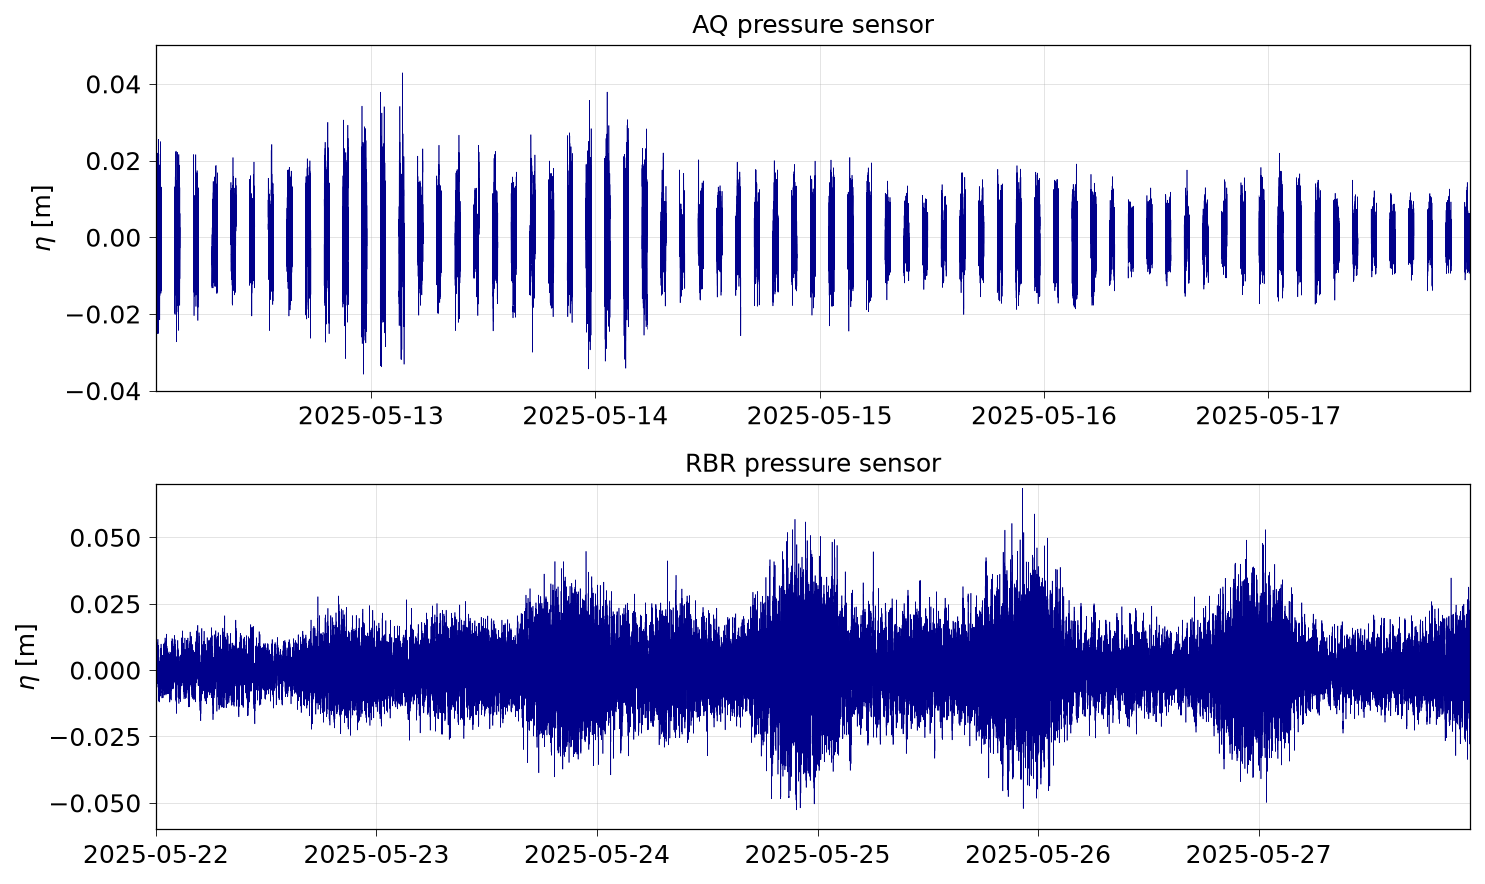

In [53]:
ylims = {'AQ': (-0.04, 0.05), 'RBR': (-0.06, 0.07)}

fig, ax = plt.subplots(2,1,figsize=(10,6),sharex=False)
for idx,metadata in enumerate(metadata_list):
    eta = dict_clean_measurements[metadata]['eta[m]'].copy()
    dt = eta.index.to_series().diff()
    eta[dt > 2*dt.median()] = np.nan
    ax[idx].plot(eta.index,eta,color='darkblue', lw=0.3)
    ax[idx].set_ylabel(r'$\eta$ [m]')
    ax[idx].set_title(f'{metadata} pressure sensor')
    ax[idx].grid(alpha=0.4, linewidth=0.4)
    ax[idx].set_ylim(ylims[metadata])
    for label in ax[idx].get_xticklabels():
        label.set_rotation(0)
        label.set_ha('center')
    for name in ('x','y'):
        axis = ax[idx].xaxis if name=='x' else ax[idx].yaxis
        lim = ax[idx].get_xlim() if name=='x' else ax[idx].get_ylim()
        major = axis.get_majorticklocs()
    ax[idx].tick_params(which='minor', direction='out')
fig.tight_layout()

## Analysis

Now, previois processed observations will be analyzed for wave params estimation by temporal and spectral methods

### Import libraries

In [43]:
from oceanicospy.analysis import temporal
from oceanicospy.analysis import spectral
from oceanicospy.plots import *

### Temporal wave parameters estimation

In [44]:
wave_params_dfs = dict()
for idx,metadata in enumerate(metadata_list):
    TemporalAnalyzer = temporal.WaveTemporalAnalyzer(dict_clean_measurements[metadata],
                                                     sampling_data[idx])
    print(f"The {metadata} sensor data is being analyzed using {type(TemporalAnalyzer)}")
    wave_params_dfs[metadata_list[idx]] = TemporalAnalyzer.compute_params_from_zero_upcrossing()

The AQ sensor data is being analyzed using <class 'oceanicospy.analysis.temporal.WaveTemporalAnalyzer'>
The following bursts have been removed due to incorrect length: [72]
The RBR sensor data is being analyzed using <class 'oceanicospy.analysis.temporal.WaveTemporalAnalyzer'>
The following bursts have been removed due to incorrect length: [144]


In [45]:
#Quick check on dataframes
wave_params_dfs['AQ'].head()

,H1/3,Tmean
time,,
2025-05-12 01:00:00,0.137625,13.127994
2025-05-12 03:00:00,0.149663,12.474390
2025-05-12 05:00:00,0.109776,12.132015
2025-05-12 07:00:00,0.124505,10.327230
2025-05-12 09:00:00,0.124143,13.018086


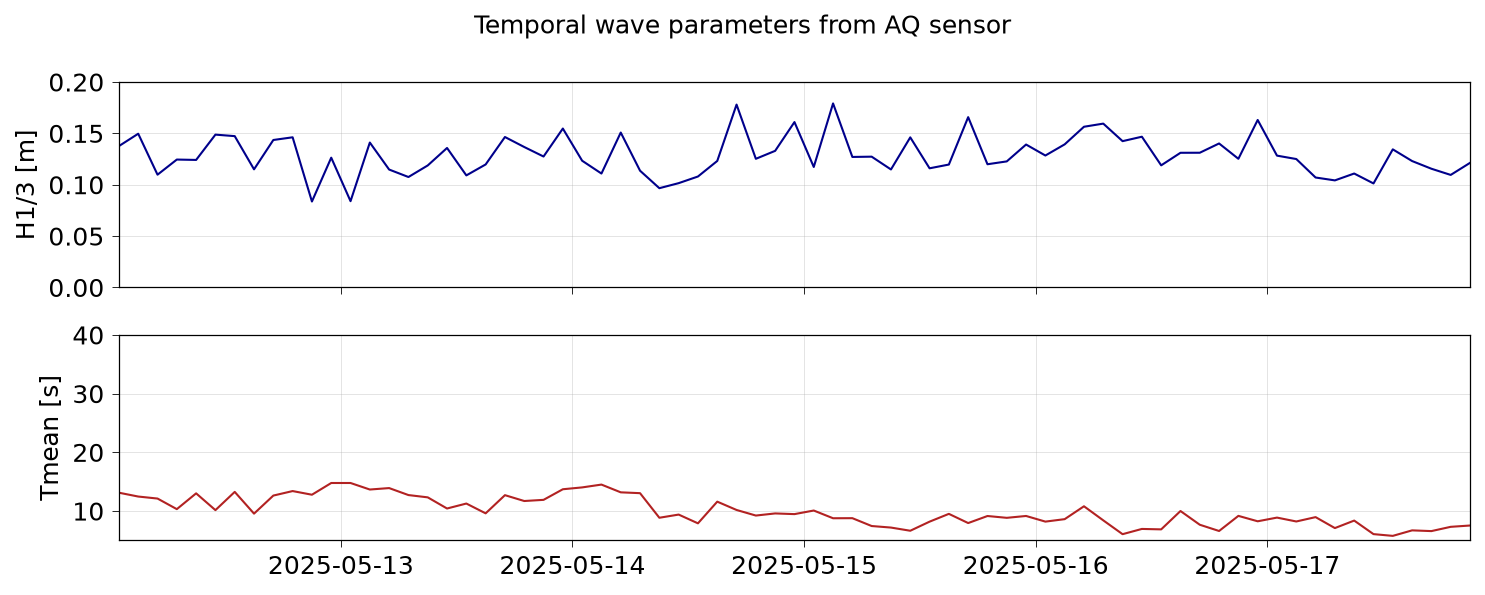

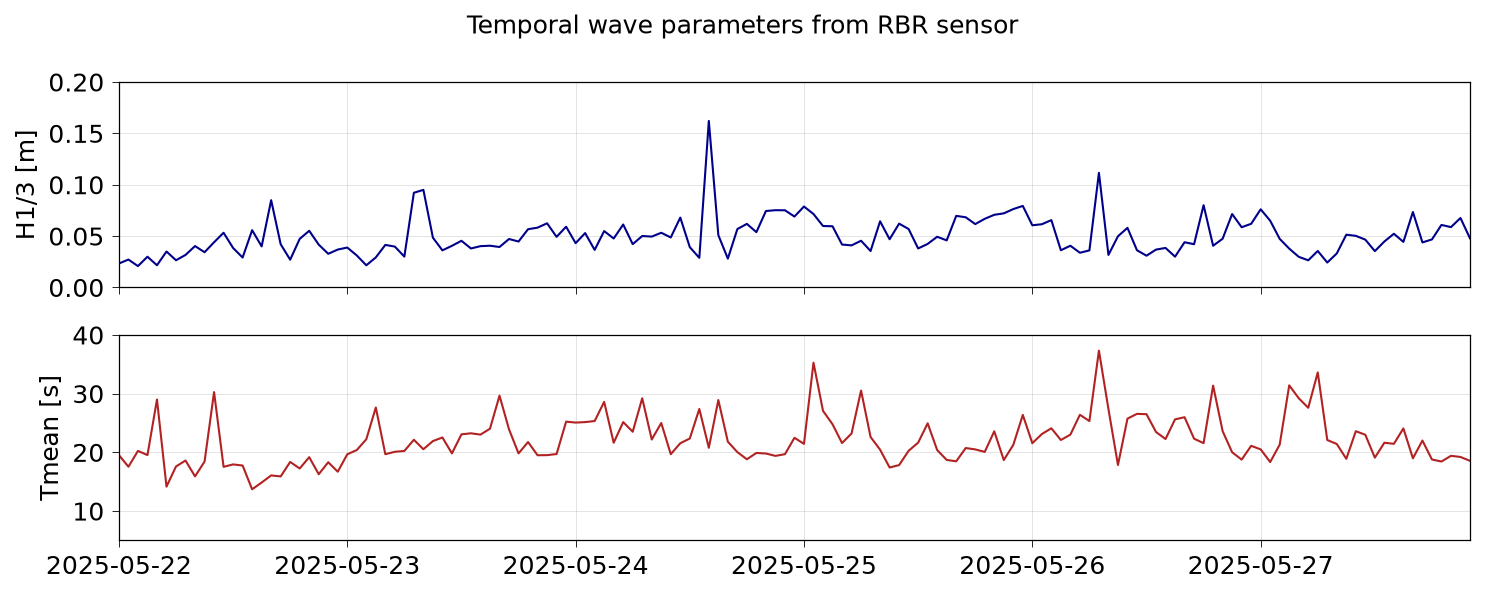

In [54]:
ylims_H = {'AQ': (0, 0.2), 'RBR': (0, 0.2)}
ylims_T = {'AQ': (5, 40), 'RBR': (5, 40)}

for idx,metadata in enumerate(metadata_list):
    fig, ax = plt.subplots(2,1,figsize=(10,4),sharex=True)
    ax[0].plot(wave_params_dfs[metadata].index,wave_params_dfs[metadata]['H1/3'],color='darkblue', lw=1)
    ax[0].set_ylabel('H1/3 [m]')
    ax[0].grid(alpha=0.4,linewidth=0.4)
    ax[0].set_ylim(ylims_H[metadata])
    ax[0].tick_params(labelbottom=False)

    ax[1].plot(wave_params_dfs[metadata].index,wave_params_dfs[metadata]['Tmean'],color='firebrick', lw=1)
    ax[1].set_ylabel('Tmean [s]')
    ax[1].grid(alpha=0.4,linewidth=0.4)
    ax[1].set_ylim(ylims_T[metadata])
    for label in ax[1].get_xticklabels():
        label.set_rotation(0)
        label.set_ha('center')

    fig.suptitle(f"Temporal wave parameters from {metadata} sensor")
    fig.subplots_adjust(hspace=0.08)
    fig.tight_layout()
    plt.show()

### Spectral wave parameters estimation

In [47]:
dict_spectra_welch = dict()
dict_integral_params_welch = dict()
dict_spectra_fft = dict()
dict_integral_params_fft = dict()

for idx,metadata in enumerate(metadata_list):
    SpectralAnalyzer = spectral.WaveSpectralAnalyzer(dict_clean_measurements[metadata],sampling_data[idx])
    print(type(SpectralAnalyzer))

    spectra_welch,params_welch = SpectralAnalyzer.get_spectra_and_params_for_bursts(method='welch',
                                                                                    kp_correction=False,
                                                                                    ig_split=True,
                                                                                    freq_split=0.04, 
                                                                                    window_type='hamming',
                                                                                    window_length=1024,
                                                                                    overlap=512,
                                                                                    smoothing_bins=6)
    spectra_fft,params_fft = SpectralAnalyzer.get_spectra_and_params_for_bursts(method='fft',
                                                                                kp_correction=False,
                                                                                ig_split=True,
                                                                                freq_split=0.04)

    dict_spectra_welch[metadata_list[idx]] = spectra_welch
    dict_integral_params_welch[metadata_list[idx]] = params_welch
    dict_spectra_fft[metadata_list[idx]] = spectra_fft
    dict_integral_params_fft[metadata_list[idx]] = params_fft

INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0036 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0007 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0006 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0008 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0013 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0006 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0006 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0016 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0011 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0007 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 

<class 'oceanicospy.analysis.spectral.WaveSpectralAnalyzer'>


INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0007 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0020 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0013 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0006 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0019 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0009 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0007 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0018 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0009 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0009 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 

<class 'oceanicospy.analysis.spectral.WaveSpectralAnalyzer'>


INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0010 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0031 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0011 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0020 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0010 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0014 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0010 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0013 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0021 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 0.0009 seconds to run.
INFO:WaveSpectralAnalyzer:Function 'compute_spectrum_from_welch' took 

In [48]:
dict_integral_params_welch['AQ'].head()

,Hm0,Hrms,Hmean,Tp,Tm01,Tm02,time,Hm0_ig,Hm0_sw
date,,,,,,,,,
2025-05-12 01:00:00,0.036068,0.025479,0.022580,204.800000,26.855341,13.001155,2025-05-12 01:00:00,0.031699,0.015324
2025-05-12 03:00:00,0.033713,0.023815,0.021105,256.000000,27.786927,12.277584,2025-05-12 03:00:00,0.030180,0.012957
2025-05-12 05:00:00,0.025474,0.017995,0.015947,256.000000,24.934993,10.655178,2025-05-12 05:00:00,0.022562,0.009868
2025-05-12 07:00:00,0.022511,0.015901,0.014092,256.000000,22.428117,9.615137,2025-05-12 07:00:00,0.020155,0.007773
2025-05-12 09:00:00,0.026564,0.018765,0.016630,341.333333,30.557403,11.458326,2025-05-12 09:00:00,0.024427,0.008229


In [49]:
dict_spectra_welch['AQ'].keys()

dict_keys(['S', 'dir', 'freq', 'time'])

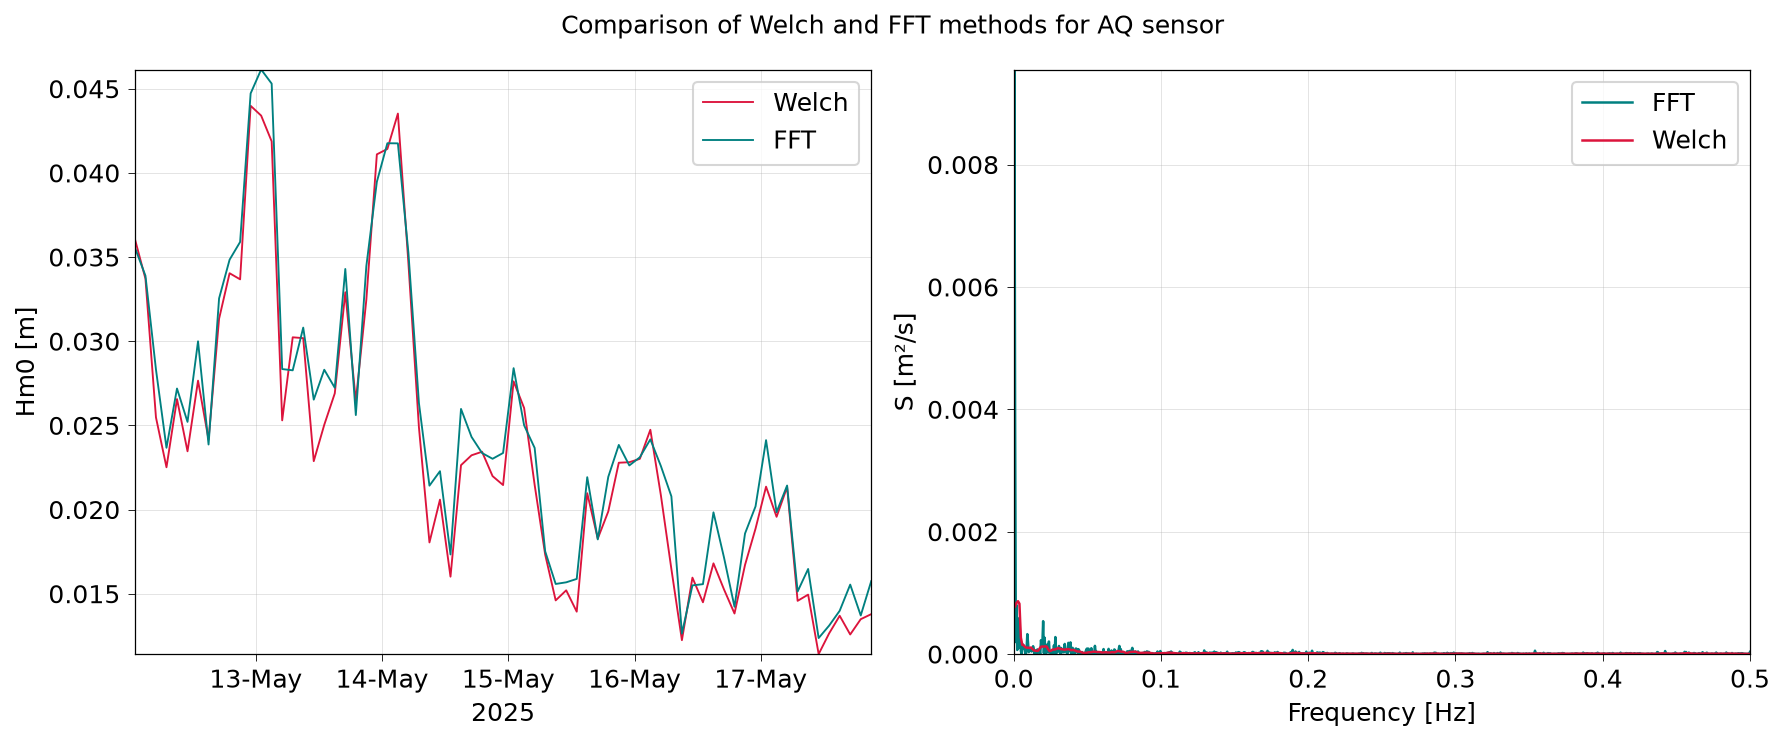

In [69]:
fig, ax = plt.subplots(1,2,figsize=(12,5),sharex=False)
ax[0].plot(dict_integral_params_welch['AQ'].index,dict_integral_params_welch['AQ']['Hm0'],label='Welch',color='crimson')
ax[0].plot(dict_integral_params_fft['AQ'].index,dict_integral_params_fft['AQ']['Hm0'],label='FFT',color='teal')
ax[0].set_ylabel('Hm0 [m]')
ax[0].set_xlabel('2025')
ax[0].grid(alpha=0.4,linewidth=0.4)
ax[0].legend()
ax[0].xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4,maxticks=6))
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
for label in ax[0].get_xticklabels():
    label.set_rotation(0)
    label.set_ha('center')

ax[1].plot(dict_spectra_fft['AQ']['freq'],dict_spectra_fft['AQ']['S'][-1],label='FFT',color='teal', lw=1.2)
ax[1].plot(dict_spectra_welch['AQ']['freq'],dict_spectra_welch['AQ']['S'][-1],label='Welch',color='crimson', lw=1.2)
ax[1].set_ylabel('S [m²/s]')
ax[1].set_xlabel('Frequency [Hz]')
ax[1].grid(alpha=0.4,linewidth=0.4)
ax[1].legend()
fig.suptitle('Comparison of Welch and FFT methods for AQ sensor')
fig.tight_layout()


## GIS

### Import libraries

In [55]:
import pandas as pd
import geopandas as gpd

from oceanicospy.gis import (
    XYZFormatSpec,
    PointFileIO,
    PointFileReprojector,
    reproject_points,
    XYZMerger,
    AxisAlignedRectangle,
    XYZRectangleMask,
    ProfileAxis,
    ProfileInterpolator,
    Grid
)

### Read and reproject from xyz file

In [56]:
xyz_input_path = "../data/oceanicospy-example/gis/bathymetries/raw/SAI_50m/bat_sai_50m.txt"
xyz_output_path = "../data/oceanicospy-example/gis/bathymetries/processed/bat_sai_50m_9377_from_xyz.xyz"

reproject_points(
    input_path=xyz_input_path,
    output_path=xyz_output_path,
    target_epsg=9377,
    source_epsg=4326,
)

### Read and reproject from shp files

In [57]:
shp_path = "../data/oceanicospy-example/gis/bathymetries/raw/SAI_200m/bat_sai_200m.shp"
preview = PointFileIO(shp_path)
df_preview = preview.read()
print(df_preview.columns.tolist())
print(preview.read_as_geodataframe().crs)

['X', 'Field2', 'Y', 'Field4', 'Z', 'x', 'y']
EPSG:4326


In [58]:
vector_reprojected_path = "../data/oceanicospy-example/gis/bathymetries/processed/bat_sai_200m_9377_from_shp.xyz"

reproject_points(
    input_path=shp_path,
    output_path=vector_reprojected_path,
    target_epsg=9377,
    z_column="Z",
)

### Correct z orientation for topography

In [59]:
xyz_path = "../data/oceanicospy-example/gis/bathymetries/processed/MDE_SAI_2m_2020_ColenMapas_EPSG9377.xyz"
reader = PointFileIO(xyz_path)
df = reader.read()
df.head()

,x,y,z
0,4.051612e+06,2.965632e+06,-0.120000
1,4.051614e+06,2.965632e+06,-0.100710
2,4.051616e+06,2.965632e+06,-0.024262
3,4.051618e+06,2.965632e+06,-0.052570
4,4.051620e+06,2.965632e+06,-0.120000


In [60]:
df_topo = df[df['z'] >= 0]
df_topo['z'] = -df_topo['z']  # Invert the sign of the 'z' values for topography

save_path = "../data/oceanicospy-example/gis/bathymetries/processed/MDE_SAI_2m_2020_ColenMapas_EPSG9377_zdown.xyz"
writer = PointFileIO(save_path)
writer.write(df_topo)

### Merging files

In [61]:
tiles_dir = "../data/oceanicospy-example/gis/bathymetries/processed/"
merged_path = "../data/oceanicospy-example/gis/bathymetries/processed/bat_sai_50m_200m_9377_merged.xyz"

priority = [
    "MDE_SAI_2m_2020_ColenMapas_EPSG9377_zdown.xyz",  # highest priority
    "bat_sai_50m_9377_from_xyz.xyz",   
    "bat_sai_200m_9377_from_shp.xyz",  # lowest priority
]

merger = XYZMerger(
    input_dir=tiles_dir,
    priority=priority,
    crs=9377,
)

In [62]:
df_merged = merger.run_merge(merged_path)
df_merged.head()

,x,y,z
0,4070045.441,2940105.090,1909.419
1,4069847.849,2940111.440,1926.113
2,4069650.255,2940117.792,1932.791
3,4069452.661,2940124.146,1897.840
4,4069255.066,2940130.501,1915.992


In [63]:
df_merged['z'].describe()

count    6.853619e+06
mean    -5.169789e+00
std      1.342902e+02
min     -9.999000e+03
25%     -3.281600e+01
50%     -5.221000e+00
75%     -2.148000e+00
max      2.406706e+03
Name: z, dtype: float64

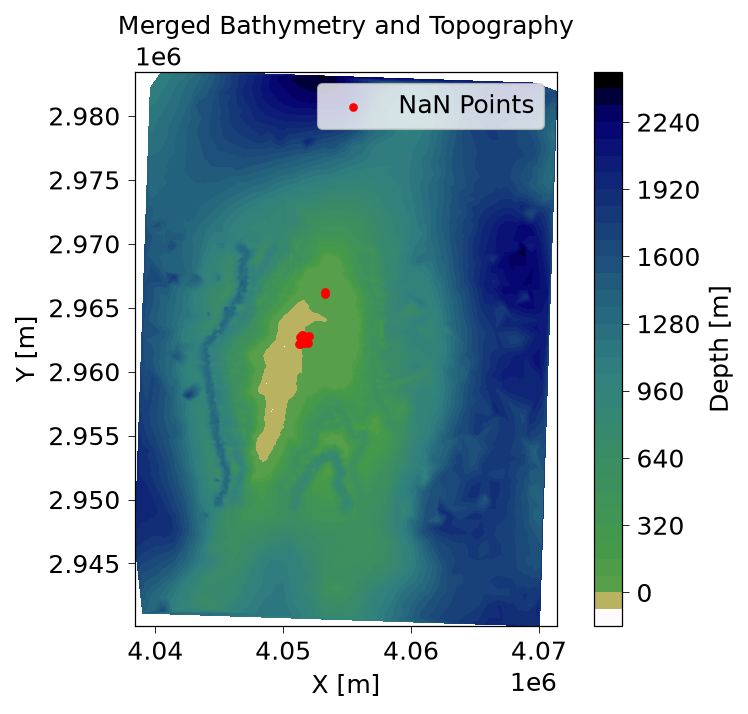

In [105]:
data = df_merged[::20]
nan_points = data[data['z'] == -9999]
data = data.drop(nan_points.index)

#Custom colorbar
vmin, vmax = min(data['z']), max(data['z'])

norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=vmin, vmax=vmax)

tcf = plt.tricontourf(data['x'], data['y'], data['z'], levels=40, cmap='gist_earth_r', norm=norm)
plt.axis('scaled')
plt.colorbar(tcf, label='Depth [m]')

plt.scatter(nan_points['x'], nan_points['y'], c='red', s=10, label='NaN Points', zorder=5)

plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.title('Merged Bathymetry and Topography')
plt.legend()

## Models

### SWAN 2D

#### Import libraries

In [108]:
from oceanicospy.models.swanpy import Initializer
from oceanicospy.models.swanpy.preprocess import *
from oceanicospy.models.swanpy.execution import CaseRunner
from oceanicospy.models.swanpy.postprocess import SwanOutputReader
from oceanicospy.plots import *

#### Case configuration

In [109]:
domains = {
    1: {
        "grid": dict(lon_ll_corner=278.2, lat_ll_corner=12.4, x_extent=0.2, y_extent=0.3, nx=222, ny=333),
        "bathy": dict(lon_ll_corner_bot=278.1811, lat_ll_corner_bot=12.372, nx_bot=322, ny_bot=422, dx_bot=0.0009, dy_bot=0.0009),
        "fric": dict(lon_ll_corner_fric=278.1811, lat_ll_corner_fric=12.372, nx_fric=322, ny_fric=422, dx_fric=0.0009, dy_fric=0.0009),
        "wind": dict(lon_ll_corner_wind=278, lat_ll_corner_wind=12.3, nx_wind=24, ny_wind=24, dx_wind=0.025, dy_wind=0.025),
        "wl":   dict(lon_ll_corner_wl=278.1811, lat_ll_corner_wl=12.372, nx_wl=322, ny_wl=422, dx_wl=0.0009, dy_wl=0.0009),
        "parent": None
    },
    2: {
        "grid": dict(lon_ll_corner=278.2265167, lat_ll_corner=12.4413166, x_extent=0.13185, y_extent=0.1908, nx=293, ny=424),
        "bathy": dict(lon_ll_corner_bot=278.2265167, lat_ll_corner_bot=12.4413166, nx_bot=293, ny_bot=424, dx_bot=0.00045, dy_bot=0.00045),
        "wind": dict(lon_ll_corner_wind=278, lat_ll_corner_wind=12.3, nx_wind=24, ny_wind=24, dx_wind=0.025, dy_wind=0.025),
        "wl":   dict(lon_ll_corner_wl=278.2265167, lat_ll_corner_wl=12.4413166, nx_wl=293, ny_wl=424, dx_wl=0.00045, dy_wl=0.00045),
        "fric": dict(lon_ll_corner_fric=278.2265167, lat_ll_corner_fric=12.4413166, nx_fric=293, ny_fric=424, dx_fric=0.00045, dy_fric=0.00045),
        "parent": 1
    },
    3: {
        "grid": dict(lon_ll_corner=278.270165, lat_ll_corner=12.550217, x_extent=0.0747, y_extent=0.0747, nx=332, ny=332),
        "bathy": dict(lon_ll_corner_bot=278.270165, lat_ll_corner_bot=12.550217, nx_bot=332, ny_bot=332, dx_bot=0.000225, dy_bot=0.000225),
        "wind": dict(lon_ll_corner_wind=278, lat_ll_corner_wind=12.3, nx_wind=24, ny_wind=24, dx_wind=0.025, dy_wind=0.025),
        "wl":   dict(lon_ll_corner_wl=278.270165, lat_ll_corner_wl=12.550217, nx_wl=332, ny_wl=332, dx_wl=0.000225, dy_wl=0.000225),
        "fric": dict(lon_ll_corner_fric=278.270165, lat_ll_corner_fric=12.550217, nx_fric=332, ny_fric=332, dx_fric=0.000225, dy_fric=0.000225),
        "parent": 2
    }}

In [4]:
path_case = '../data/oceanicospy-example/model_runs/nonstationary_swan/'

ini_date = datetime(2025, 5, 10, 0)
end_date = datetime(2025, 5, 17, 23)

dict_ini_data = dict(
    name             = 'Non-stationary',
    case_number      = 1,
    case_description = 'Example non-stationary case for San Andres',
    stat_id          = 0, # 0 → non-stationary
    number_domains   = len(domains),
    parent_domains   = {d:cfg["parent"] for d, cfg in domains.items()})

#### Initializer

In [5]:
case = Initializer(
    root_path     = path_case,
    dict_ini_data = dict_ini_data,
    ini_date      = ini_date,
    end_date      = end_date,
)

# case.create_folders()       # creates all project folders
# case.replace_ini_data()     # writes run.swn from the NONSTAT template

*** Initializing SWAN model ***



#### Configure grid

In [6]:
for domain_id,config in domains.items():
    domain_grid_dict = config["grid"]
    case_grid = GridMaker(init = case,
                          domain_number = domain_id, 
                          grid_info = domain_grid_dict)
    case_grid.fill_grid_section()


*** Initializing gridmaker for domain 1 ***


 	*** Adding/Editing grid information for domain 1 in configuration file ***


*** Initializing gridmaker for domain 2 ***


 	*** Adding/Editing grid information for domain 2 in configuration file ***


*** Initializing gridmaker for domain 3 ***


 	*** Adding/Editing grid information for domain 3 in configuration file ***



#### Configure bathymetry

In [7]:
# Create a regular target grid
merged_path='../data/oceanicospy-example/gis/bathymetries/processed/bat_sai_50m_200m_9377_merged.xyz'
reader_geo = PointFileIO(merged_path, crs=9377)
gdf = reader_geo.read_as_geodataframe()
gdf = gdf.to_crs(epsg=4326)  # Reproject to WGS84 for consistency
gdf = gdf[gdf != -9999]  # Filter out invalid depth values

In [8]:
from scipy.interpolate import griddata

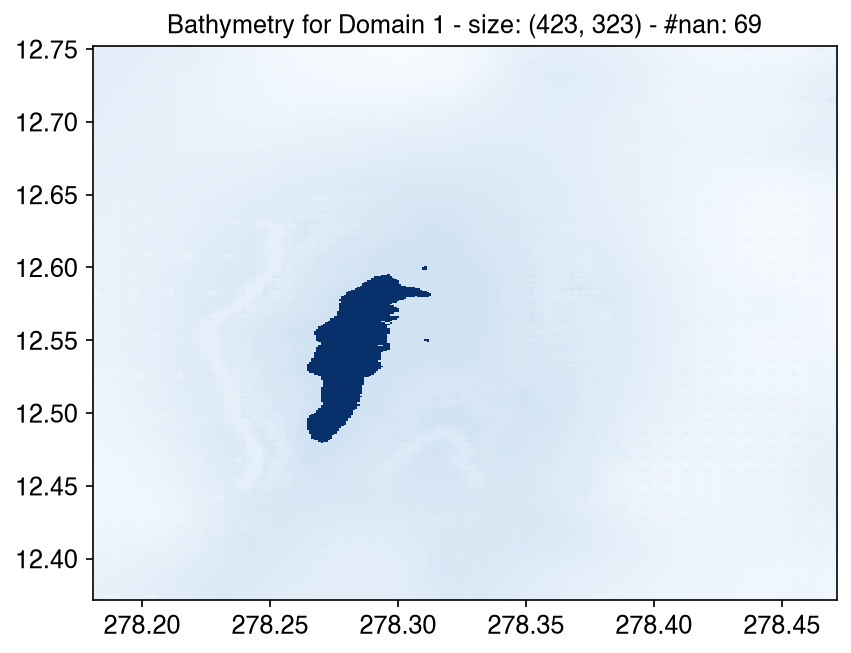

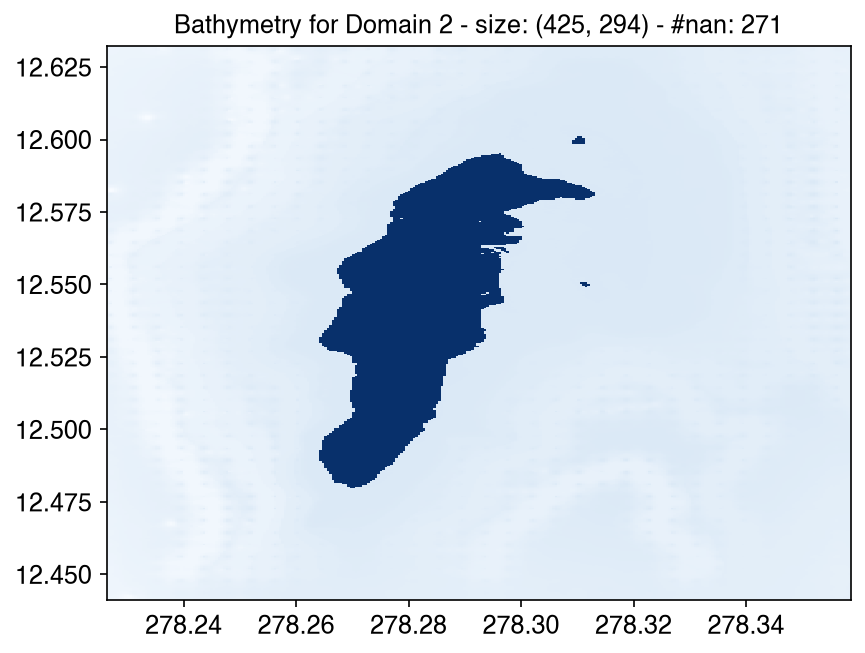

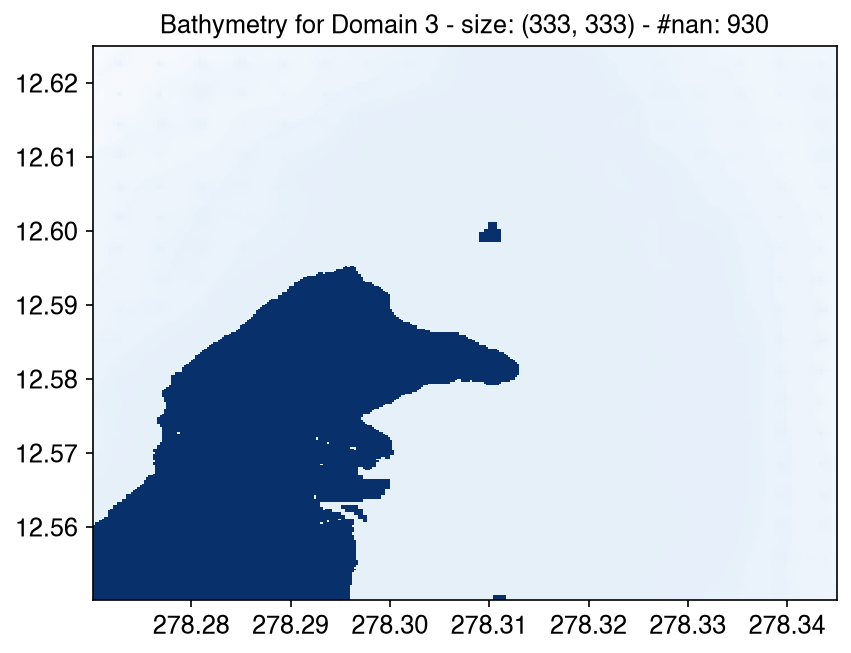

In [9]:
for d in list(domains.keys()):
    d_info=domains[d]['bathy']
    grid_x, grid_y = np.meshgrid(np.linspace(d_info['lon_ll_corner_bot'], d_info['lon_ll_corner_bot']+d_info['nx_bot']*d_info['dx_bot'], d_info['nx_bot']+1),
                                  np.linspace(d_info['lat_ll_corner_bot'], d_info['lat_ll_corner_bot']+d_info['ny_bot']*d_info['dy_bot'], d_info['ny_bot']+1))

    # Run the interpolation
    grid_z = griddata((gdf['geometry'].x.values+360, gdf['geometry'].y.values), gdf['z'].values, (grid_x, grid_y), method='nearest')
    grid_z2 = grid_z.copy()
    grid_z2[np.isnan(grid_z2)] = -9999  # Replace invalid values with NaN for better handling
    grid_z2[grid_z2 < 0] = -9999
    np.savetxt(f'{path_case}input/domain_0{d}/bot{d}.bot', grid_z2, delimiter=' ', fmt='%.4f')
    plt.pcolormesh(grid_x, grid_y, grid_z2, shading='auto', cmap='Blues_r')
    plt.title(f"Bathymetry for Domain {d} - size: {grid_z.shape} - #nan: {np.isnan(grid_z).sum()}")
    plt.show()

In [10]:
for domain_id,config in domains.items():
    domain_bathy_dict = config["bathy"]
    case_bathy = BathyMaker(init = case,
                          domain_number = domain_id, 
                          bathy_info = domain_bathy_dict)
    case_bathy.use_ascii_file_from_user()
    case_bathy.fill_bathy_section()


*** Initializing bathymaker for domain 1 ***


 	*** Adding/Editing bathymetry information for domain 1 in configuration file ***


*** Initializing bathymaker for domain 2 ***


 	*** Adding/Editing bathymetry information for domain 2 in configuration file ***


*** Initializing bathymaker for domain 3 ***


 	*** Adding/Editing bathymetry information for domain 3 in configuration file ***



#### Configure boundary conditions

##### Wind

In [11]:
for domain_id,config in domains.items():
    domain_wind_dict = config["wind"]
    case_wind = WindForcing(init = case,
                          domain_number = domain_id, 
                          wind_info = domain_wind_dict)
    
    # Skips download if the file already exists in input/domain_01/
    case_wind.get_winds_from_ERA5(utc_offset_hours=-5, format_localtime=True)

    # Convert localtime NetCDF → SWAN ASCII and link into run/domain_01/
    case_wind.write_ERA5_ascii('winds_era5_localtime.nc', 'winds.wnd')
    case_wind.fill_wind_section()


*** Initializing winds for domain 1 ***

the file ../data/oceanicospy-example/model_runs/nonstationary_swan/input/domain_01/winds_era5.nc already exists
	 ERA5 wind data already exists, skipping download
	 ERA5 wind data converted to ASCII format and saved as winds.wnd

 	*** Adding/Editing winds information for domain 1 in configuration file ***


*** Initializing winds for domain 2 ***

	 ERA5 wind data already exists in domain 1, skipping download
	 ERA5 wind data converted to ASCII format and saved as winds.wnd in domain 01, linking to domain 2

 	*** Adding/Editing winds information for domain 2 in configuration file ***


*** Initializing winds for domain 3 ***

	 ERA5 wind data already exists in domain 1, skipping download
	 ERA5 wind data converted to ASCII format and saved as winds.wnd in domain 01, linking to domain 3

 	*** Adding/Editing winds information for domain 3 in configuration file ***



##### Water level

In [ ]:
for domain_id,config in domains.items():
    domain_wl_dict = config["wl"]
    case_wl = WaterLevelForcing(init = case,
                          domain_number = domain_id, 
                          wl_info = domain_wl_dict)
    df_wl = case_wl.get_waterlevel_from_UHSLC(station_id=737)
    
    # # mask application
    # correction_mask = (
    #     (df_wl.index >= datetime(1997, 1, 1, 0)) &
    #     (df_wl.index <= datetime(2018, 12, 31, 18))
    # )
    df_wl.loc[:, "depth[m]"] -= 2

    case_wl.write_UHSLC_ascii(df_wl, 'water_levels.wl')

    #Convert CSV → SWAN ASCII
    case_wl.fill_wl_section()


*** Initializing water levels for domain 1 ***

the file ../data/oceanicospy-example/model_runs/nonstationary_swan/input/domain_01/h737.csv already exists
	 UHSLC water level data already exists, skipping download
	 UHSLC water level data converted to ASCII format and saved as water_levels.wl

 	*** Adding/Editing water level information for domain 1 in configuration file ***


*** Initializing water levels for domain 2 ***

	 UHSLC water level data already exists in domain 1, skipping download
	 UHSLC water level data converted to ASCII format and saved as water_levels.wl

 	*** Adding/Editing water level information for domain 2 in configuration file ***


*** Initializing water levels for domain 3 ***

	 UHSLC water level data already exists in domain 1, skipping download
	 UHSLC water level data converted to ASCII format and saved as water_levels.wl

 	*** Adding/Editing water level information for domain 3 in configuration file ***



##### Waves

In [13]:
# Boundary point arrays — define the lat/lon grid of boundary sample points
lat_boundaries_dom01 = [12.40,12.50,12.60,12.70]
lon_boundaries_dom01 = [-81.80,-81.70,-81.60]

In [14]:
for domain_id,config in domains.items():
    domain_wind_dict = config["wind"]
    case_boundary = BoundaryConditions(
        init          = case,
        domain_number = domain_id,
        bound_info     = {'bound_type': 'side','variable_bound': True},
    )

    # Step 1 – download ERA5 wave parameters for the boundary region
    case_boundary.get_waves_from_ERA5(
        utc_offset_hours = -5,
        wind_info_dict    = domain_wind_dict,
        format_localtime  = True)
    
    # Step 2 - extract time series at boundary corners and write .bnd TPAR files
    case_boundary.tpar_from_ERA5(
        points_lat = lat_boundaries_dom01,
        points_lon = lon_boundaries_dom01,
    )

    # Step 3 - create the BOUN lines for the .swn file
    case_boundary.create_boundary_line(list_sides=['N','S','E','W'], 
                                       points_lon=lon_boundaries_dom01,
                                       points_lat=lat_boundaries_dom01)

    case_boundary.fill_boundaries_section()


*** Initializing boundary conditions for domain 1 ***

the file ../data/oceanicospy-example/model_runs/nonstationary_swan/input/domain_01/waves_era5.nc already exists
	 ERA5 wave data already exists, skipping download
	*** Finished processing boundary files for domain 1 ***


 	*** Adding/Editing boundary information for domain 1 in configuration file ***


*** Initializing boundary conditions for domain 2 ***


 	*** Adding/Editing boundary information for domain 2 in configuration file ***


*** Initializing boundary conditions for domain 3 ***


 	*** Adding/Editing boundary information for domain 3 in configuration file ***



#### Computation

In [15]:
_common = dict(                                                                                                                   
    ini_output_date = (ini_date + timedelta(days=5)),                                                     
    output_res_min  = 60,
    stat_comp       = 0,                                                                                                            
    dt_min          = 10,                                                                                                         
    end_comp_date   = end_date,                                                                           
)

compilation_data = {
    1: {**_common, "ini_comp_date": ini_date,                                                             
                    "ini_nest_date": ini_date + timedelta(days=2)},                                      
    2: {**_common, "ini_comp_date": ini_date + timedelta(days=2),                                       
                    "ini_nest_date": ini_date + timedelta(days=2)},                                      
    3: {**_common, "ini_comp_date": ini_date + timedelta(days=2)},                                                                            
}  

In [16]:
for domain_id, config in domains.items():
    case_compilation = CaseRunner(
        init          = case,
        domain_number = domain_id,
        dict_comp_data= compilation_data[domain_id],
        all_domains   = domains
    )

    # Write output point locations from CSV (X, Y columns)
    case_compilation.define_output_from_file(filename='SalidasSWAN.txt')

    # Remove NESTOUT/NGRID template lines (single-domain has no child domains)
    case_compilation.write_nest_section()

    # Write the COMP command and output date/interval placeholders
    case_compilation.fill_computation_section()


*** Initializing Case Runner for domain 1 ***


 	*** Adding/Editing compilation information for domain 1 in configuration file ***


*** Initializing Case Runner for domain 2 ***


 	*** Adding/Editing compilation information for domain 2 in configuration file ***


*** Initializing Case Runner for domain 3 ***


 	*** Adding/Editing compilation information for domain 3 in configuration file ***



#### Output reading

##### Waves

In [110]:
out_reader = SwanOutputReader(n_points=3)
path_case = '../data/oceanicospy-example/model_runs/nonstationary_swan/201344012/'

# Domain to post-process — change to explore other domains
DOMAIN_ID = 3
output_dir = f'{path_case}run/domain_{DOMAIN_ID:02d}/'

In [111]:
point_df = out_reader.read_point_output(
    output_dir = output_dir,
    filename   = 'PointSWAN.out'
)
point_df.head()

Xp       Yp    Depth  X-Windv  Y-Windv  \
time                point                                                
2025-05-15 00:00:00 1      278.300  12.5755   6.0532  -7.1856  -2.0534   
                    2      278.310  12.5724   1.1335  -7.1876  -2.0584   
                    3      278.326  12.5674  12.5716  -7.1908  -2.0668   
2025-05-15 01:00:00 1      278.300  12.5755   6.0532  -7.1856  -2.0534   
                    2      278.310  12.5724   1.1335  -7.1876  -2.0584   

                              Hsig  TPsmoo    Tm01    Tm02      Dir  
time                point                                            
2025-05-15 00:00:00 1      0.24316  1.8316  1.4967  1.3726  102.498  
                    2      0.24331  1.7315  1.4785  1.3135   74.491  
                    3      1.44688  8.0451  4.7990  3.8587   76.439  
2025-05-15 01:00:00 1      0.24324  1.8269  1.4897  1.3636  102.380  
                    2      0.24252  1.7313  1.4833  1.3196   74.419

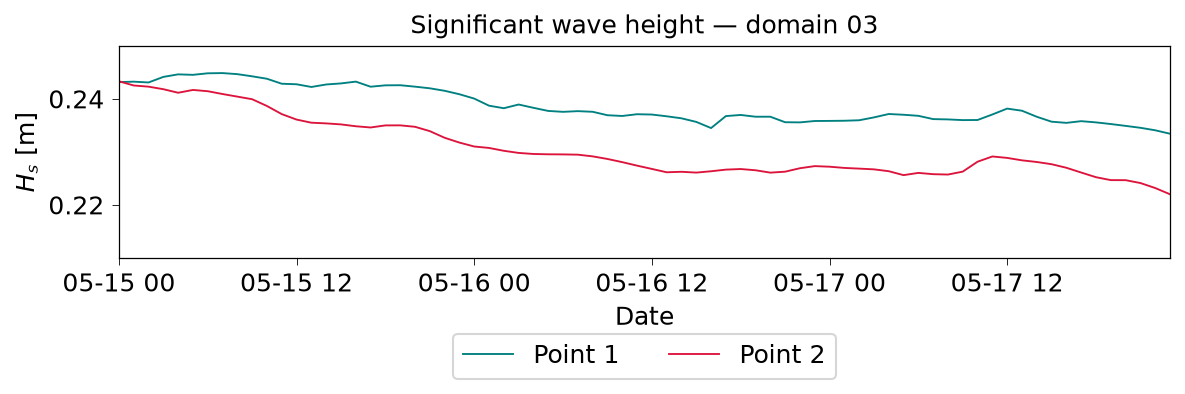

In [112]:
fig, ax = plt.subplots(figsize=(8, 3))
colors = ['teal','crimson']
for i,(pt, grp) in enumerate(list(point_df.groupby(level='point'))[:2]):
    ax.plot(grp.index.get_level_values('time'), grp['Hsig'], label=f'Point {pt}', color=colors[i])
ax.set(xlabel='Date', ylabel='$H_s$ [m]', ylim=(0.21, 0.25), title=f'Significant wave height — domain {DOMAIN_ID:02d}')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=2, frameon=True)
plt.tight_layout()
plt.show()

##### Spectra

In [113]:
wave_spectra = out_reader.read_spectral_output(
    output_dir = output_dir,
    filename   = 'SpecSWAN.out'
)

wave_spectra

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 72, site: 3, freq: 35, dir: 36)
Coordinates:
  * time     (time) datetime64[us] 576B 2025-05-15 ... 2025-05-17T23:00:00
  * site     (site) int64 24B 1 2 3
  * freq     (freq) float64 280B 0.04 0.044 0.0483 0.0531 ... 0.8275 0.9097 1.0
  * dir      (dir) float64 288B 5.0 15.0 25.0 35.0 ... 325.0 335.0 345.0 355.0
Data variables:
    efth     (time, site, freq, dir) float64 2MB 0.0 0.0 ... 9.329e-06 1.399e-05
    lat      (site) float64 24B 12.58 12.57 12.57
    lon      (site) float64 24B 278.3 278.3 278.3

In [116]:
# Select the time step to visualise (−1 = last snapshot)
t_idx = -1

theta,r = np.meshgrid(wave_spectra.dir.values, wave_spectra.freq.values)
theta_rad = np.deg2rad(theta)
# Closing the wave spectra to make a complete polar plot of the directional distribution
theta_rad = np.append(theta_rad, theta_rad[:,0:1]+2*np.pi, axis=1)
r = np.append(r, r[:,0:1], axis=1)
efth_closed = np.append(wave_spectra['efth'][t_idx,:,:,:].values, 
                        wave_spectra['efth'][t_idx,:,:,0:1].values, axis=2)

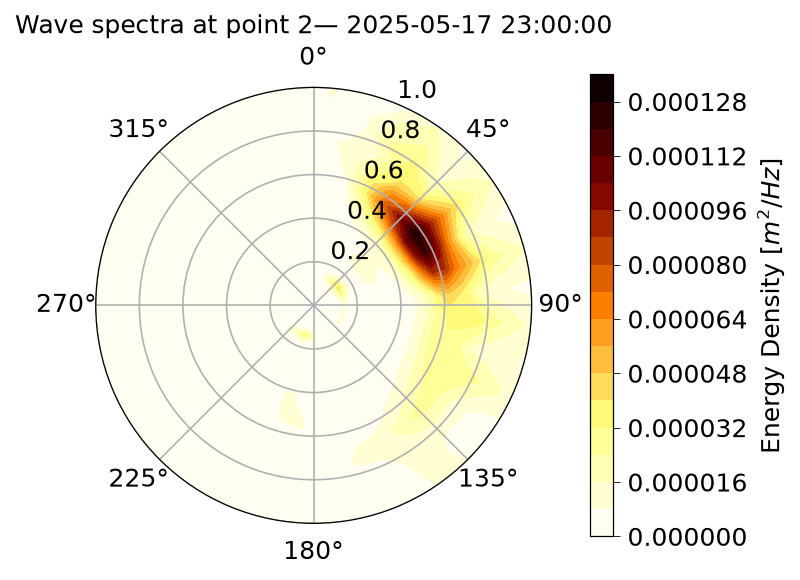

In [118]:
point_idx = 1
freq_1d = r[:,0]
energy_by_freq = efth_closed[point_idx,:,:].sum(axis=1)
peak_freq = freq_1d[np.argmax(energy_by_freq)]
r_lim = min(freq_1d.max(), 3*peak_freq)

point_idx=1
fig, ax = plt.subplots(figsize=(5, 4), subplot_kw={'projection': 'polar'})
cf = ax.contourf(theta_rad, r, efth_closed[point_idx, :, :],
                  levels=20, cmap='afmhot_r')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set(ylim=(0, r_lim))
plt.colorbar(cf, label='Energy Density [$m^2/Hz$]', pad=0.1)
ax.set_title(f"Wave spectra at point {wave_spectra.site.values[point_idx]}— {pd.to_datetime(wave_spectra.time.values[t_idx])}")
plt.show()

##### Spatial

In [66]:
grid_info = domains[DOMAIN_ID]['grid']

wave_field_ds = out_reader.read_spatial_output(
    output_dir = output_dir,
    filename   = 'wave_field.mat',
    grid_info  = grid_info
)

wave_field_ds

E:\JuanDiego\oceanicospy\oceanicospy\models\swanpy\postprocess\output_reader.py:217: RuntimeWarning: invalid value encountered in cast
  np.stack([snapshots[d] for d in date_strings], axis=0).astype(float),


<xarray.Dataset> Size: 255MB
Dimensions:  (time: 72, lat: 333, lon: 333)
Coordinates:
  * time     (time) datetime64[us] 576B 2025-05-15 ... 2025-05-17T23:00:00
  * lat      (lat) float64 3kB 12.55 12.55 12.55 12.55 ... 12.62 12.62 12.62
  * lon      (lon) float64 3kB 278.3 278.3 278.3 278.3 ... 278.3 278.3 278.3
Data variables:
    Hsig     (time, lat, lon) float64 64MB nan nan nan nan ... 1.263 1.263 1.263
    TPsmoo   (time, lat, lon) float64 64MB nan nan nan nan ... 6.865 6.865 6.865
    Tm01     (time, lat, lon) float64 64MB nan nan nan nan ... 4.195 4.195 4.199
    Tm02     (time, lat, lon) float64 64MB nan nan nan nan ... 3.43 3.428 3.439

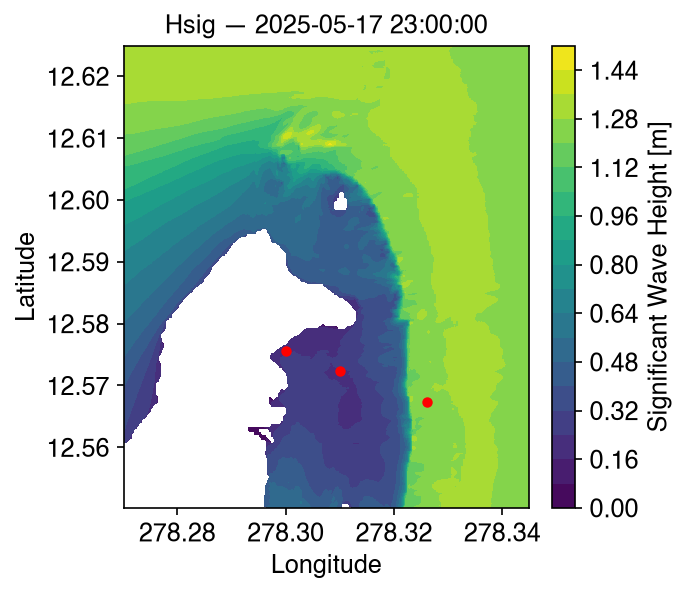

In [67]:
# Reuse t_idx from the spectra cell; change as needed
unique_pts = point_df[['Xp', 'Yp']].drop_duplicates()

fig, ax = plt.subplots(figsize=(4, 4))
cf = ax.contourf(wave_field_ds.lon, wave_field_ds.lat,
                  wave_field_ds['Hsig'].isel(time=t_idx), levels=20)
ax.plot(unique_pts['Xp'], unique_pts['Yp'], 'ro', label='Output points', markersize=4)
ax.set(xlabel='Longitude', ylabel='Latitude',
       title=f"Hsig — {pd.to_datetime(wave_field_ds.time.values[t_idx])}")
plt.colorbar(cf, label='Significant Wave Height [m]', fraction=0.08)
plt.show()

### XBeach 1D

#### Import libraries

In [1]:
from oceanicospy.models import xbeachpy
import xarray as xr

#### Case configuration

In [4]:
# ── path to the case root ─────────────────────────────────────────────────────
path_case = '../data/oceanicospy-example/model_runs/xbeach_1d/'  # must end with a slash

# ── case-level flags written into params.txt ──────────────────────────────────
ini_case_data = dict(
    case_description='1D profile – Caribbean coast',
    act_morf=0,
    act_sedtrans=0,
    act_wavemodel=1,
    dims=1
)

# ── simulation period ─────────────────────────────────────────────────────────
ini_date = datetime(2025, 5, 15, 0)
end_date = datetime(2025, 5, 17, 23)

#### Initialization

In [5]:
case = xbeachpy.Initializer(
    root_path=path_case,
    dict_ini_data=ini_case_data,
    ini_date=ini_date,
    end_date=end_date
)
case.create_folders()
case.replace_ini_data()

*** Initializing XBeach model ***


	*** Creating project folder structure ***


	*** Copying base XBeach configuration file into run folder ***



#### Generate grid

In [6]:
grid_params_case = dict(thetamin=-20, thetamax=160, dtheta=180, alfa = 161)

In [7]:
case_grid = xbeachpy.preprocess.GridMaker(init=case,grid_params=grid_params_case)

In [8]:
# Build the profile axis from two planar endpoint coordinates (projected, metres)
profile_axis = case_grid.build_profile.from_coordinates(
    start = (4054866.827, 2962460.496),
    end = (4051803.311, 2963542.255),
    dx=5.0,                   # uniform spacing [m]
    auto_extend=True,
)

In [9]:
profile_axis.distance_axis

,s
0,0.0
1,5.0
2,10.0
3,15.0
4,20.0
...,...
646,3230.0
647,3235.0
648,3240.0
649,3245.0


In [10]:
profile_axis.coordinates

,x,y
0,4.054867e+06,2.962460e+06
1,4.054862e+06,2.962462e+06
2,4.054857e+06,2.962464e+06
3,4.054853e+06,2.962465e+06
4,4.054848e+06,2.962467e+06
...,...,...
646,4.051821e+06,2.963536e+06
647,4.051816e+06,2.963538e+06
648,4.051812e+06,2.963539e+06
649,4.051807e+06,2.963541e+06


In [11]:
case_grid.fill_grid_section()


*** Adding/Editing grid information in params file ***



#### Bathymetry set-up

In [12]:
case_bathy = xbeachpy.preprocess.BathyMaker(init=case)

In [13]:
shutil.copyfile('../data/oceanicospy-example/gis/bathymetries/processed/bat_sai_50m_200m_9377_merged.xyz',
                f'{path_case}input/bat_sai_50m_200m_9377_merged.xyz')

'../data/oceanicospy-example/model_runs/xbeach_1d/input/bat_sai_50m_200m_9377_merged.xyz'

In [14]:
case_bathy.build_z_from_bathy(xyz_filepath='bat_sai_50m_200m_9377_merged.xyz',
                              geometry_object=profile_axis)

E:\JuanDiego\oceanicospy\oceanicospy\models\xbeachpy\preprocess\bathymaker.py:96: UserWarning: No CRS was provided to ProfileAxis. Cannot verify that the profile coordinates and the XYZ dataset share the same coordinate reference system. Ensure both are in the same projected CRS before interpolating.
  interpolator = ProfileInterpolator(axis=geometry_object, xyz=bathy_xyz_df)


In [15]:
case_bathy.fill_bathy_section()


*** Adding/Editing bathymetry information in params file ***



#### Wind

In [16]:
wind_dict = dict(
    lon_ll_corner_wind=-82,
    lat_ll_corner_wind=12.567536, 
    nx_wind=1,
    ny_wind=1,
    dx_wind=0.025,
    dy_wind=0.025
)

In [17]:
case_winds = xbeachpy.preprocess.WindForcing(
    init=case,
    wind_info=wind_dict,
    use_link=False
)


*** Initializing winds ***



In [18]:
case_winds.get_winds_from_ERA5(utc_offset_hours=-5, format_localtime=True)

the file ../data/oceanicospy-example/model_runs/xbeach_1d/input/winds_era5.nc already exists
	 ERA5 wind data already exists, skipping download


In [19]:
case_winds.write_ERA5_ascii(
    era5_filename='winds_era5_localtime.nc',
    ascii_filename='winds.wnd',
    lon_target=278.326063-360,
    lat_target=12.567536
)
case_winds.fill_wind_section()

	 ERA5 wind data converted to ASCII format and saved as winds.wnd

*** Adding/Editing winds information in params file ***



#### Water level (Tides)

In [20]:
case_wl = xbeachpy.preprocess.WaterLevelForcing(init=case, use_link=False)
df_wl = case_wl.get_waterlevel_from_UHSLC(station_id=737)


*** Initializing water levels ***

the file ../data/oceanicospy-example/model_runs/xbeach_1d/input/h737.csv already exists
	 UHSLC water level data already exists, skipping download


In [21]:
df_wl.loc[:, "depth[m]"] -= 2.0

In [22]:
case_wl.write_UHSLC_ascii(df_wl, 'water_levels.wl')
case_wl.fill_wl_section()

	 UHSLC water level data converted to ASCII format and saved as water_levels.wl

*** Adding/Editing water level information in params file ***



#### Boundary conditions (Waves)

In [23]:
case_bounds = xbeachpy.preprocess.BoundaryConditions(init=case)

*** Cleaning Boundary Conditions ***
*** Initializing Boundary Conditions ***


In [24]:
shutil.copyfile('../data/oceanicospy-example/model_runs/nonstationary_swan/201344012/run/domain_03/SpecSWAN.out',
                f'{path_case}input/SpecSWAN.out')

'../data/oceanicospy-example/model_runs/xbeach_1d/input/SpecSWAN.out'

In [25]:
case_bounds.spectra_from_swan(input_filename='SpecSWAN.out', 
                              location_points=[(0,0)],
                              point_indexes=[2])

In [26]:
case_bounds.fill_boundaries_section()


*** Adding/Editing boundary information for domain in configuration file ***



#### Output and configuration

In [27]:
# ── computation / output settings ─────────────────────────────────────────────
comp_data_nonstat = dict(
    tint_value=3600,    # output interval [s]
    tintg_value=3600,   # global output interval [s]
    tstart_value=3600.   # start time for outputs [s]
)

In [28]:
case_output = xbeachpy.execution.CaseRunner(
    init=case,
    dict_comp_data=comp_data_nonstat
)


*** Initializing Case Runner ***



In [29]:
from pyproj import Transformer
def point_planar_proj(lon,lat,epsg_start="EPSG:4326",epsg_end="EPSG:9377"):
    transformer = Transformer.from_crs(epsg_start, epsg_end, always_xy=True)
    # Perform the transformation
    east, north = transformer.transform(lon, lat)
    return (east, north)

In [30]:
#identify the s coordinate of outpoint points to match with sensors
sensors_coords=[(278.2998-360,12.5755),(278.30973-360,12.57241)]
scoords_9377=[point_planar_proj(e[0],e[1]) for e in sensors_coords]

xy_profile=profile_axis.coordinates
idx_sensors=[np.argmin(abs(xy_profile['x']-e[0])+abs(xy_profile['y']-e[1])) for e in scoords_9377]
output_point=np.array([np.array(idx_sensors),np.zeros(len(idx_sensors))]).T
np.savetxt(f'{path_case}/input/points_output.txt',output_point,delimiter=' ',fmt='%d')

In [31]:
# filepath for the output NetCDF file
case_output.write_output_file(filename='E1_profile1D_May2025.nc')

# selection of variables written to the global 1D output file
case_output.select_global_vars(list_vars=['zs', 'hh', 'zb0', 'H', 'u', 'urms'])

# (optional) output points along the profile
case_output.write_output_points(filename='points_output.txt')

# selection of variables at the output points
case_output.select_point_vars(list_vars=['zs', 'H', 'urms', 'Sxx'])

In [32]:
case_output.fill_computation_section()

#### Read output

In [33]:
path_case = '../data/oceanicospy-example/model_runs/xbeach_1d/'
ds_output = xr.open_dataset(f'{path_case}run/E1_profile1D_May2025.nc')

In [34]:
ds_output

<xarray.Dataset> Size: 2MB
Dimensions:      (globaltime: 72, ny: 1, nx: 651, points: 2, pointtime: 72)
Coordinates:
  * globaltime   (globaltime) float64 576B 0.0 3.6e+03 ... 2.52e+05 2.556e+05
    globalx      (ny, nx) float64 5kB ...
    globaly      (ny, nx) float64 5kB ...
    pointx       (points) float64 16B ...
    pointy       (points) float64 16B ...
  * pointtime    (pointtime) float64 576B 0.0 3.6e+03 ... 2.52e+05 2.556e+05
Dimensions without coordinates: ny, nx, points
Data variables: (12/15)
    _parameters  float64 8B ...
    zs           (globaltime, ny, nx) float64 375kB ...
    hh           (globaltime, ny, nx) float64 375kB ...
    zb0          (globaltime, ny, nx) float64 375kB ...
    H            (globaltime, ny, nx) float64 375kB ...
    u            (globaltime, ny, nx) float64 375kB ...
    ...           ...
    ypointindex  (points) int32 8B ...
    pointtypes   (points) int32 8B ...
    point_zs     (pointtime, points) float64 1kB ...
    point_H      (pointtime, points) float64 1kB ...
    point_urms   (pointtime, points) float64 1kB ...
    point_Sxx    (pointtime, points) float64 1kB ...
Attributes:
    Conventions:     CF-1.4
    Producer:        XBeach littoral zone wave model (http://www.xbeach.org)
    Build-Revision:  5528
    Build-Date:      09-11-2018 11:14:26
    URL:             http://svn.oss.deltares.nl/repos/xbeach/trunk/

In [35]:
ds_profile = ds_output[[var for var in ds_output.data_vars if ds_output[var].ndim > 2]]
ds_point = ds_output[[var for var in ds_output.data_vars if ds_output[var].ndim == 2]]

##### Profile

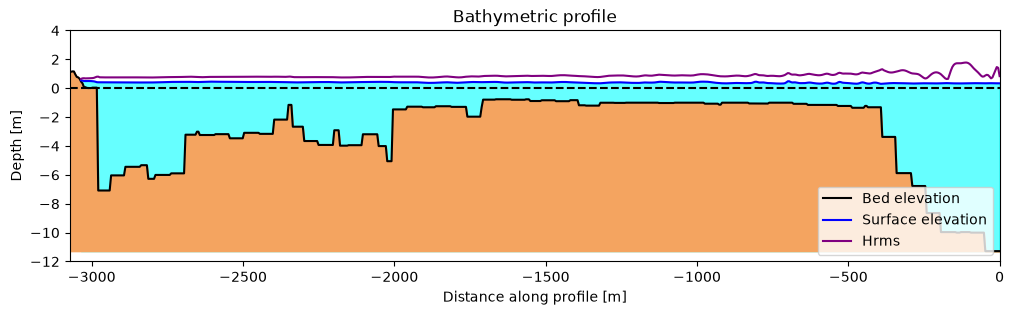

In [36]:
x = ds_profile.globalx[0,:].values

fig,ax = plt.subplots(1,1,figsize=(12,3))
ax.plot(x,ds_profile.zb0.values[-1,0,:],c='black',label='Bed elevation')
ax.plot(x,ds_profile.zs.values[-1,0,:],c='blue',label='Surface elevation')
ax.plot(x,ds_profile.hh.values[-1,0,:]+ds_profile.zb0.values[-1,0,:]+ds_profile.H.values[-1,0,:],c='purple',label='Hrms')
ax.set_title('Bathymetric profile')
ax.set(ylabel=('Depth [m]'), xlabel=('Distance along profile [m]'))
ax.fill_between(x, ds_profile.zs.values[-1,0,:],  np.min(ds_profile.zb0.values[-1,0,:]), color='aqua',alpha=0.6)
ax.fill_between(x, ds_profile.zb0.values[-1,0,:], np.min(ds_profile.zb0.values[-1,0,:]), color="sandybrown")
ax.axhline(0, c='black', ls='--')
ax.legend(loc='lower right')
ax.set(ylim=(-12, 4),xlim=(x.min(), x.max()))
plt.show()

##### Points

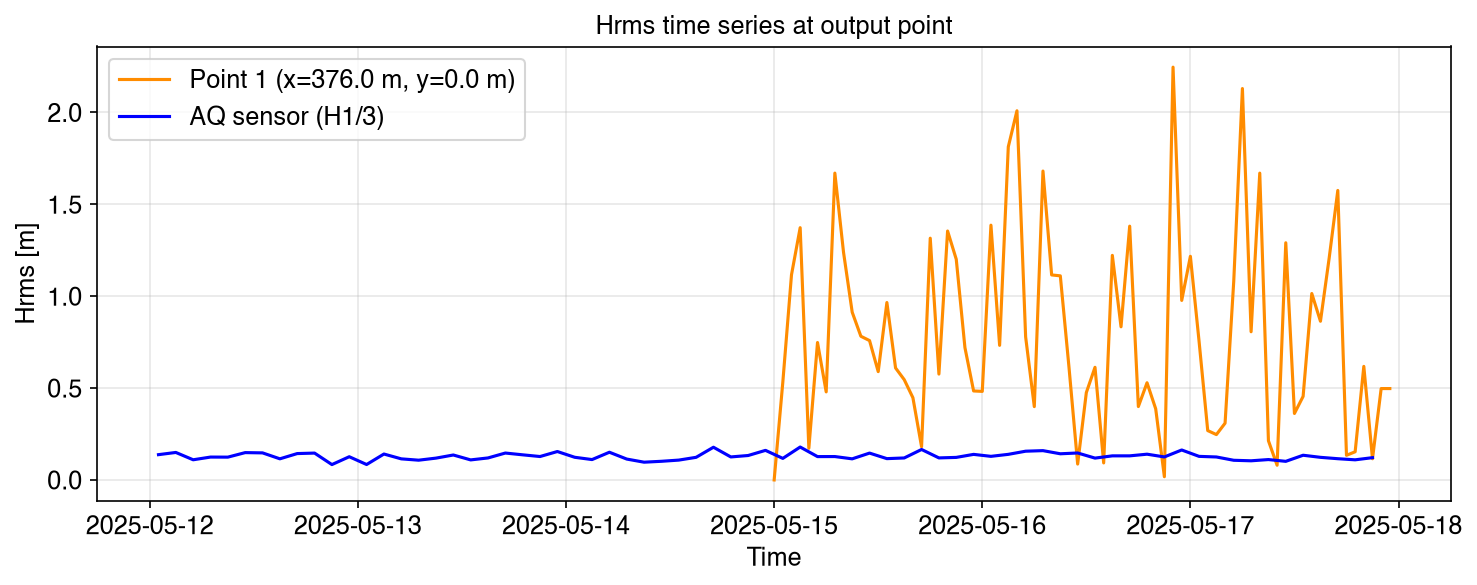

In [51]:
time = np.array([ini_date + timedelta(seconds=int(s)) for s in ds_point.pointtime.values])

H = ds_point.point_H.values

point_index = 1
px = ds_point.pointx.values[point_index]
py = ds_point.pointy.values[point_index]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time, H[:, point_index], color='darkorange', lw=1.5,
        label=f'Point {point_index} (x={px:.1f} m, y={py:.1f} m)')
ax.plot(wave_params_dfs['AQ'].index, wave_params_dfs['AQ']['H1/3'], color='blue', lw=1.5,
        label='AQ sensor (H1/3)')
ax.set(xlabel='Time', ylabel='Hrms [m]',
       title='Hrms time series at output point')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()